In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder,OrdinalEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.impute import KNNImputer
import itertools
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [2]:
df = pd.read_csv("E:\\VS code\\Applied_programming(IT park)\\New folder\\lung cancer dataset (updated).csv")

In [3]:
df.head(2)

,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,...,Shortness of Breath,Wheezing,Swallowing Difficulty,Swallowing Difficulty.1,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level,Result
0,P1,33,Male,2,4.0,5,4.0,3,2,2,...,2,2,3,3,1,2,3,4,Low,1
1,P10,17,Male,3,1.0,5,3.0,4,2,2,...,7,8,6,6,2,1,7,2,Medium,0


In [4]:
df.shape

(1000, 28)

In [5]:
df.isnull().sum()

Patient Id                   0
Age                          0
Gender                       0
Air Pollution                0
Alcohol use                 64
Dust Allergy                 0
OccuPational Hazards        50
Genetic Risk                 0
chronic Lung Disease         0
Balanced Diet                0
Obesity                     64
Smoking                     56
Smoking.1                   56
Passive Smoker               0
Chest Pain                   0
Coughing of Blood            0
Fatigue                      0
Weight Loss                 72
Shortness of Breath          0
Wheezing                     0
Swallowing Difficulty        0
Swallowing Difficulty.1      0
Clubbing of Finger Nails     0
Frequent Cold                0
Dry Cough                    0
Snoring                      0
Level                        0
Result                       0
dtype: int64

<Axes: >

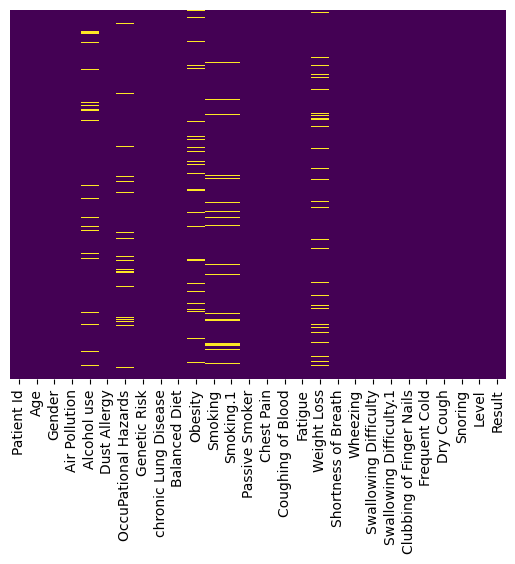

In [6]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [7]:
duplicate_bool = df.duplicated()
print(duplicate_bool)

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


In [8]:
num_duplicates = duplicate_bool.sum()
print("Number of duplicate rows:", num_duplicates)


Number of duplicate rows: 0


In [9]:
df.columns[df.T.duplicated()]

Index(['Smoking.1', 'Swallowing Difficulty.1'], dtype='object')

In [10]:
dups = df.T.duplicated(keep=False)
df.T[dups]


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
Smoking,3.0,2.0,2.0,7.0,8.0,2.0,3.0,1.0,NaN,2.0,...,2.0,8.0,7.0,7.0,7.0,7.0,7.0,2.0,8.0,2.0
Smoking.1,3.0,2.0,2.0,7.0,8.0,2.0,3.0,1.0,NaN,2.0,...,2.0,8.0,7.0,7.0,7.0,7.0,7.0,2.0,8.0,2.0
Swallowing Difficulty,3,6,1,4,4,1,3,2,4,5,...,1,4,6,4,7,8,2,1,4,1
Swallowing Difficulty.1,3,6,1,4,4,1,3,2,4,5,...,1,4,6,4,7,8,2,1,4,1


In [11]:
df.drop(['Patient Id','Smoking.1','Swallowing Difficulty.1'], axis = 1,inplace = True)

In [12]:
df.columns

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Level', 'Result'],
      dtype='object')

In [13]:
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

In [14]:
num_cols

Index(['Age', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Result'],
      dtype='object')

In [15]:
cat_cols

Index(['Gender', 'Level'], dtype='object')

In [16]:
df['Gender'].value_counts()

Gender
Male      598
Female    402
Name: count, dtype: int64

In [17]:
df['Level'].value_counts()

Level
High      365
Medium    332
Low       303
Name: count, dtype: int64

In [18]:
df.isnull().sum()

Age                          0
Gender                       0
Air Pollution                0
Alcohol use                 64
Dust Allergy                 0
OccuPational Hazards        50
Genetic Risk                 0
chronic Lung Disease         0
Balanced Diet                0
Obesity                     64
Smoking                     56
Passive Smoker               0
Chest Pain                   0
Coughing of Blood            0
Fatigue                      0
Weight Loss                 72
Shortness of Breath          0
Wheezing                     0
Swallowing Difficulty        0
Clubbing of Finger Nails     0
Frequent Cold                0
Dry Cough                    0
Snoring                      0
Level                        0
Result                       0
dtype: int64

In [19]:
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [20]:
df.isnull().sum()

Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
Result                      0
dtype: int64

In [21]:
corr = df[num_cols].corr().abs()
corr

,Age,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,Smoking,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Result
Age,1.000000,0.099494,0.143145,0.035202,0.064949,0.073151,0.128952,0.004863,0.031502,0.083565,...,0.095059,0.103122,0.035329,0.095354,0.105833,0.039258,0.012706,0.012128,0.004700,0.036527
Air Pollution,0.099494,1.000000,0.724167,0.637503,0.596790,0.705276,0.626701,0.524873,0.586698,0.461373,...,0.211724,0.233637,0.269558,0.055368,0.080918,0.241065,0.174539,0.261489,0.021343,0.009865
Alcohol use,0.143145,0.724167,1.000000,0.793018,0.824641,0.851195,0.731560,0.629113,0.625053,0.508967,...,0.224184,0.189521,0.427765,0.174649,0.110343,0.406099,0.170714,0.208486,0.110865,0.002658
Dust Allergy,0.035202,0.637503,0.793018,1.000000,0.813751,0.787904,0.619556,0.647197,0.678862,0.345667,...,0.332472,0.301724,0.518682,0.304850,0.031141,0.345714,0.219389,0.300195,0.052844,0.014696
OccuPational Hazards,0.064949,0.596790,0.824641,0.813751,1.000000,0.867532,0.833280,0.669141,0.675801,0.467717,...,0.263490,0.160103,0.354951,0.181755,0.002528,0.359603,0.072263,0.156654,0.011955,0.003407
Genetic Risk,0.073151,0.705276,0.851195,0.787904,0.867532,1.000000,0.836231,0.679905,0.714717,0.525505,...,0.230530,0.251030,0.458200,0.204973,0.062948,0.357815,0.087092,0.194399,0.056831,0.015804
chronic Lung Disease,0.128952,0.626701,0.731560,0.619556,0.833280,0.836231,1.000000,0.622632,0.584101,0.556183,...,0.247697,0.087287,0.182426,0.057214,0.007279,0.298023,0.028759,0.114161,0.043375,0.026844
Balanced Diet,0.004863,0.524873,0.629113,0.647197,0.669141,0.679905,0.622632,1.000000,0.681213,0.628839,...,0.400678,0.001035,0.343623,0.063930,0.046807,0.041967,0.263931,0.331995,0.152677,0.039401
Obesity,0.031502,0.586698,0.625053,0.678862,0.675801,0.714717,0.584101,0.681213,1.000000,0.460520,...,0.531798,0.287381,0.385274,0.103349,0.131815,0.133342,0.268893,0.174696,0.038693,0.004354
Smoking,0.083565,0.461373,0.508967,0.345667,0.467717,0.525505,0.556183,0.628839,0.460520,1.000000,...,0.196284,0.208686,0.023878,0.047607,0.224454,0.051914,0.037960,0.001807,0.182739,0.030375


<Axes: >

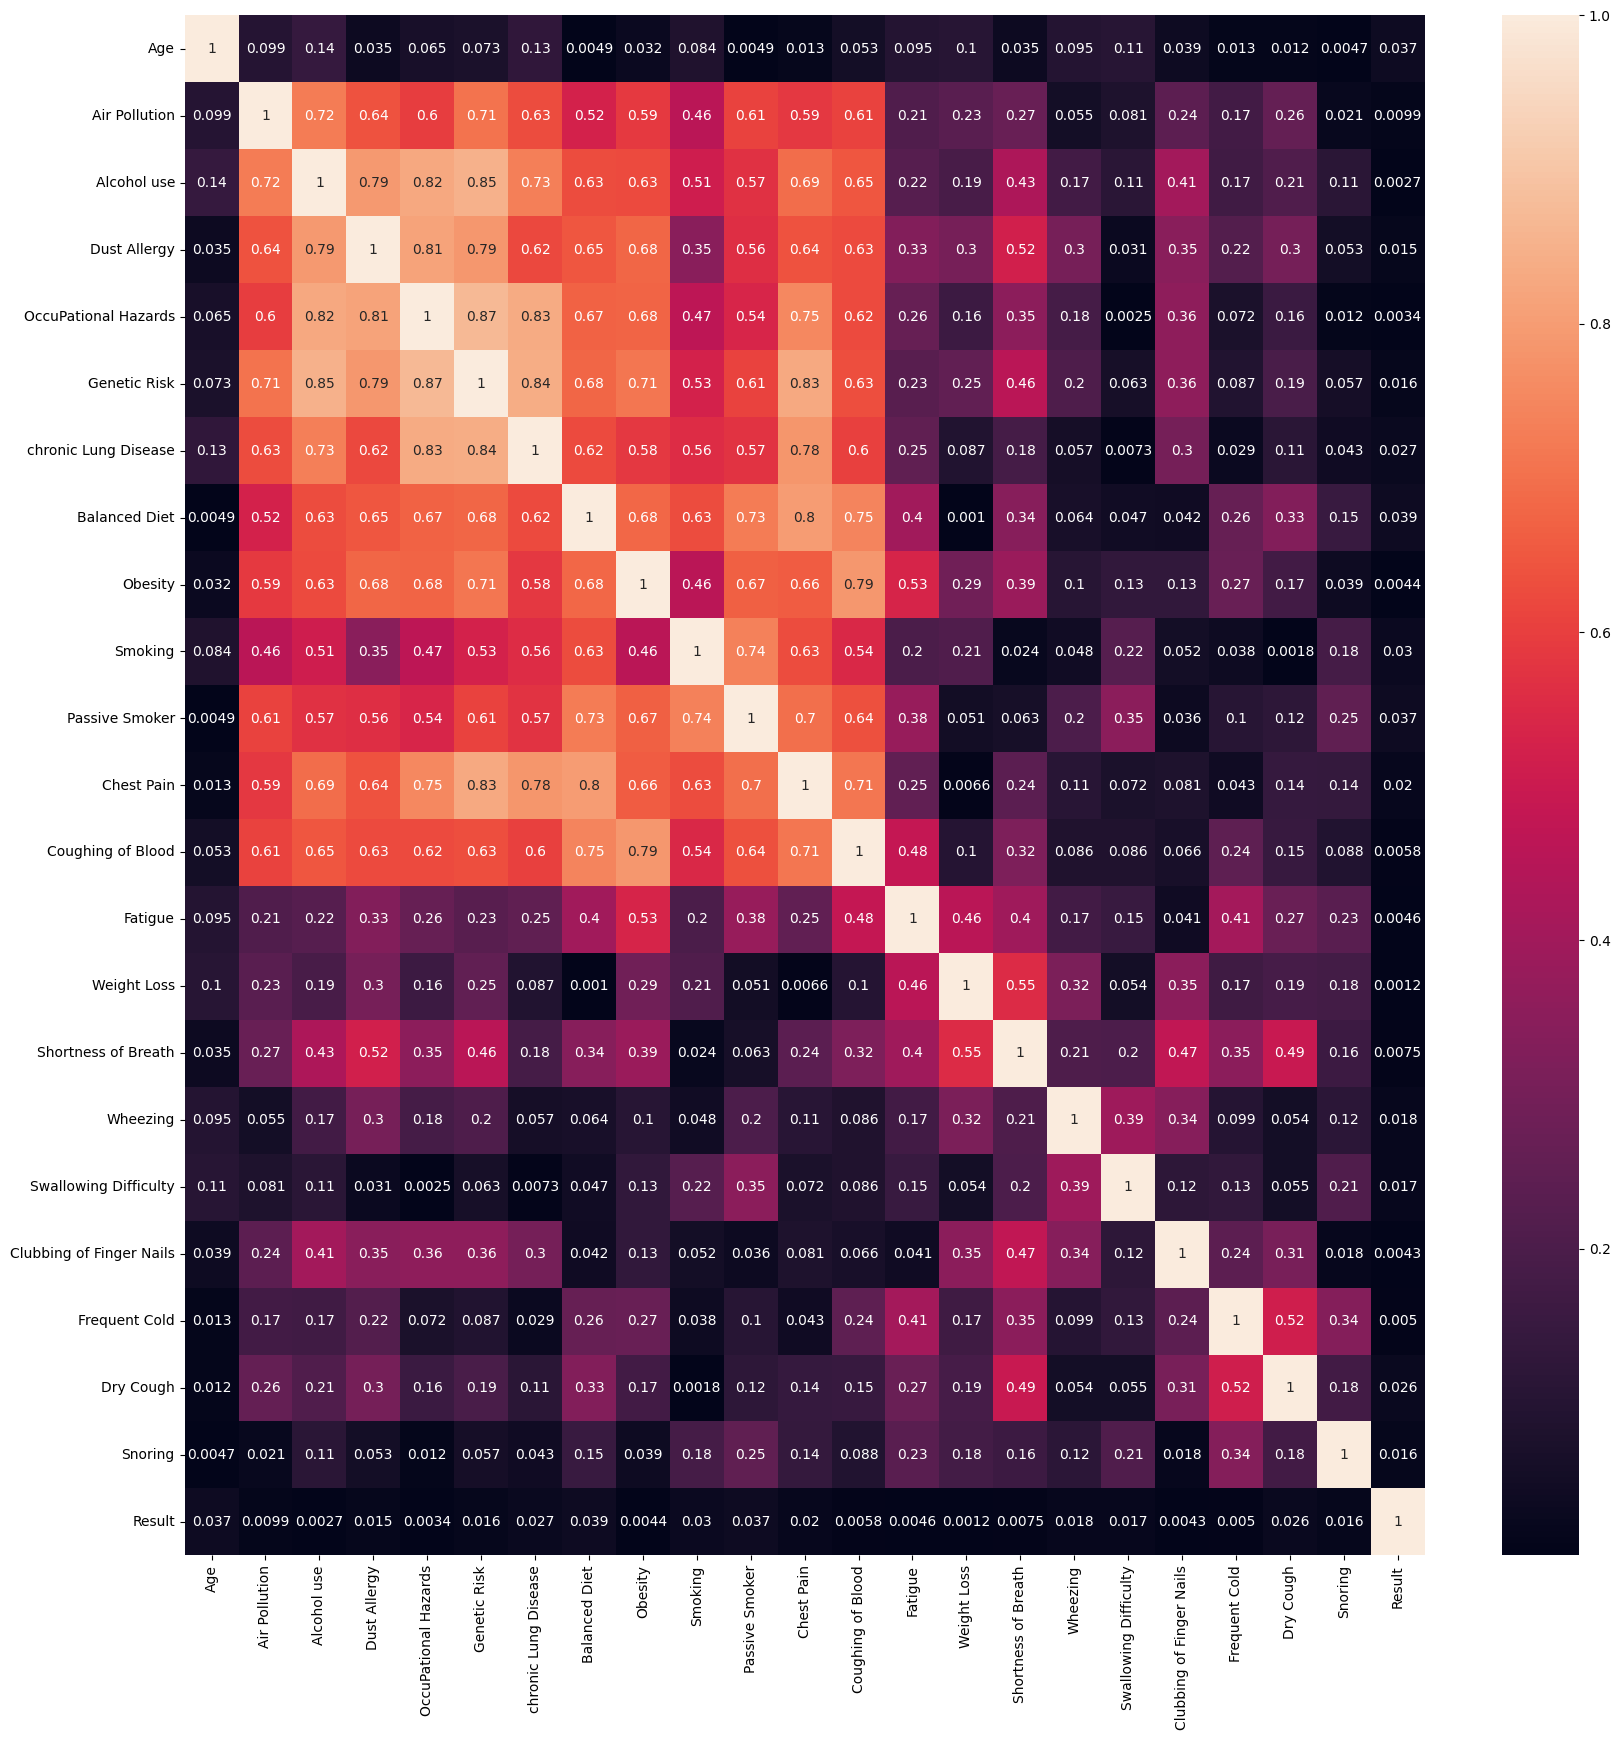

In [22]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, annot=True)

In [23]:
threshold = 0.83
upper_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_corr.columns
    if any(upper_corr[column] > threshold)
]

to_drop

['Genetic Risk', 'chronic Lung Disease', 'Chest Pain']

In [24]:
df.drop(columns=to_drop, inplace=True)

In [25]:
df.shape

(1000, 22)

In [26]:
df.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Balanced Diet,Obesity,Smoking,Passive Smoker,...,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level,Result
0,33,Male,2,4.000000,5,4.0,2,4.000000,3.0,2,...,4.0,2,2,3,1,2,3,4,Low,1
1,17,Male,3,1.000000,5,3.0,2,4.449786,2.0,4,...,3.0,7,8,6,2,1,7,2,Medium,0
2,35,Male,4,5.000000,6,5.0,6,4.449786,2.0,3,...,7.0,9,2,1,4,6,7,2,High,1
3,37,Male,7,4.541667,7,7.0,7,7.000000,7.0,7,...,2.0,3,1,4,5,6,7,5,High,0
4,46,Male,6,8.000000,7,7.0,7,7.000000,8.0,7,...,2.0,4,1,4,2,4,2,3,High,0


In [27]:
df = pd.get_dummies(df, columns = cat_cols, drop_first = True)

In [28]:
df.isnull().sum()

Age                         0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Result                      0
Gender_Male                 0
Level_Low                   0
Level_Medium                0
dtype: int64

In [29]:
df.shape

(1000, 23)

In [30]:
df.columns

Index(['Age', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Balanced Diet', 'Obesity', 'Smoking',
       'Passive Smoker', 'Coughing of Blood', 'Fatigue', 'Weight Loss',
       'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty',
       'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring',
       'Result', 'Gender_Male', 'Level_Low', 'Level_Medium'],
      dtype='object')

In [31]:
# label_Status = df['Result'].value_counts()
# transactions = label_Status.index
# quantity = label_Status.values

# figure = px.pie(values=quantity, names=transactions, hole =.50, title="Cancer & well")
# figure.show()

In [32]:
X = df.drop(['Result'], axis = 1)
y = df['Result']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()   
}


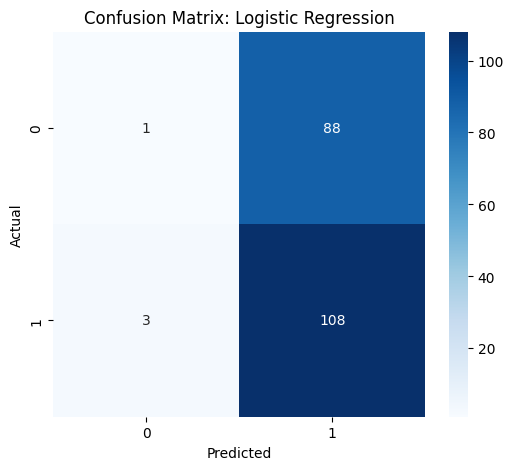

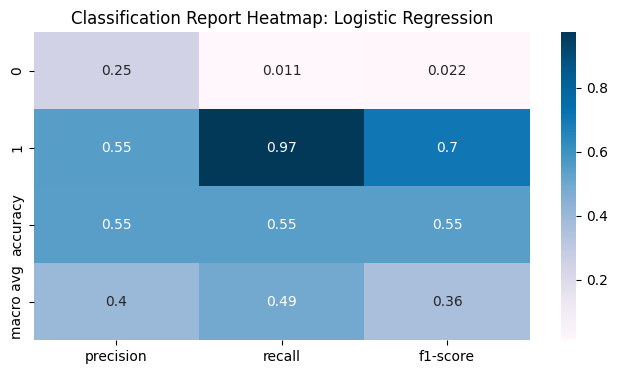

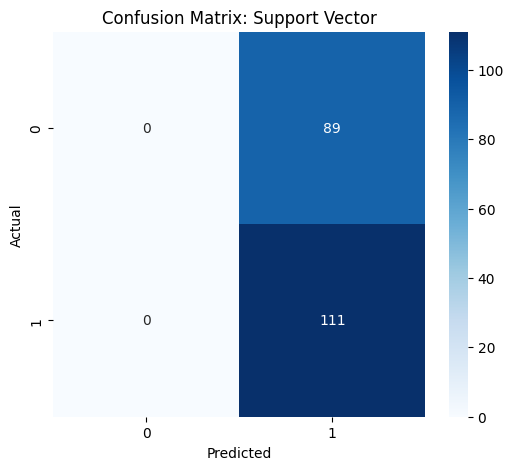

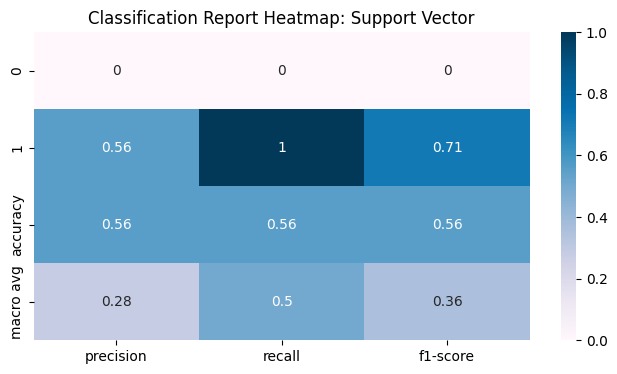

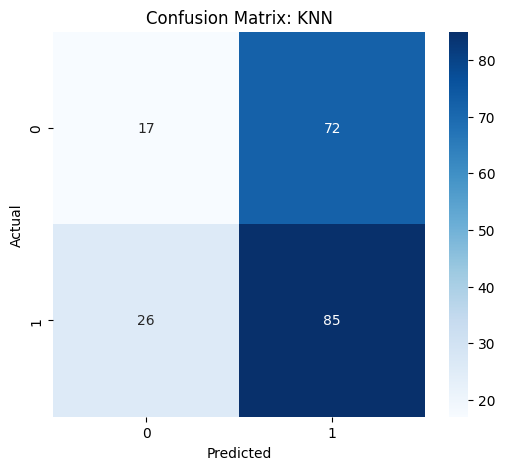

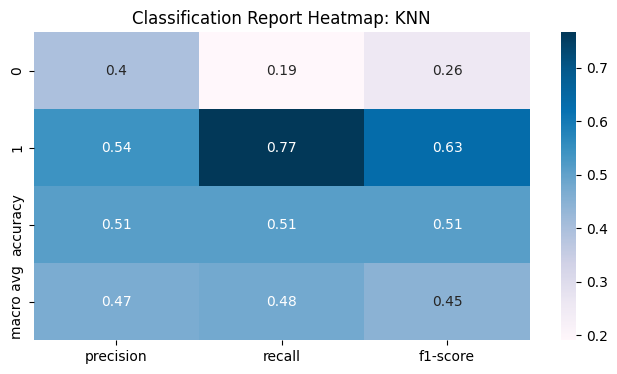

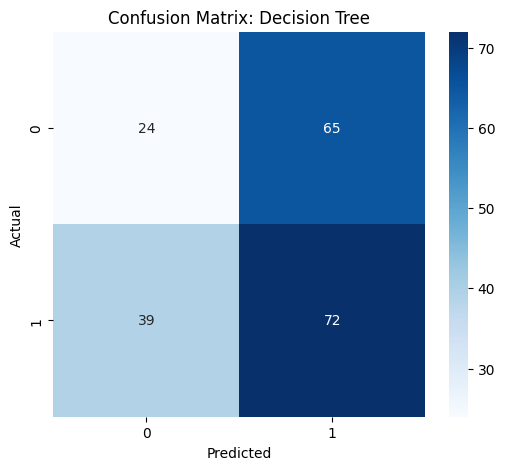

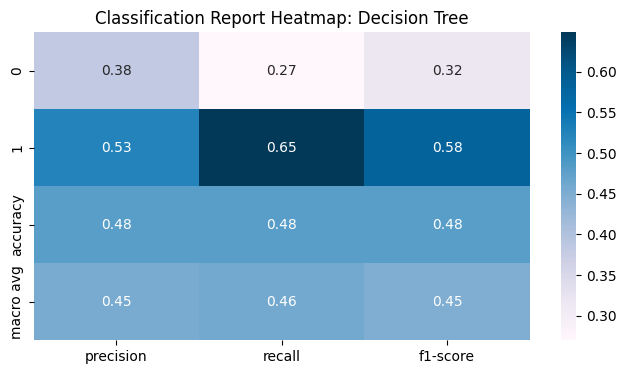

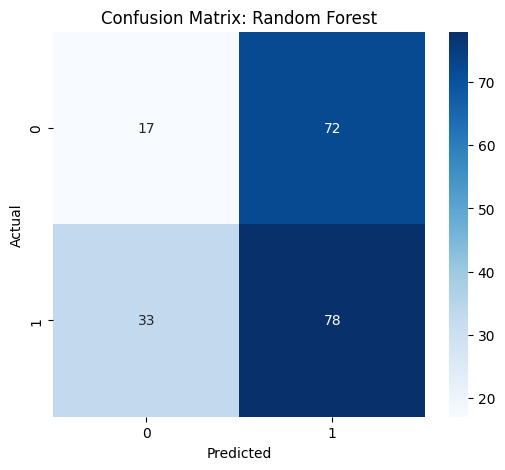

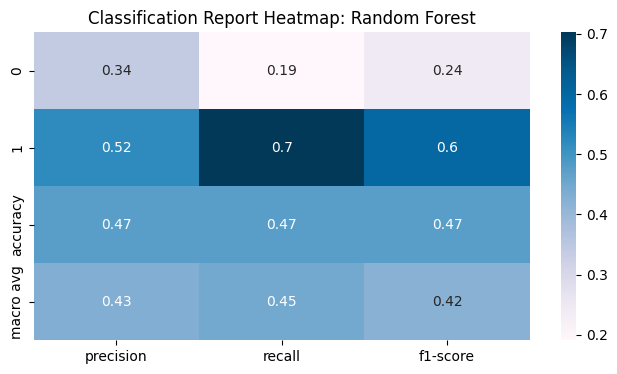

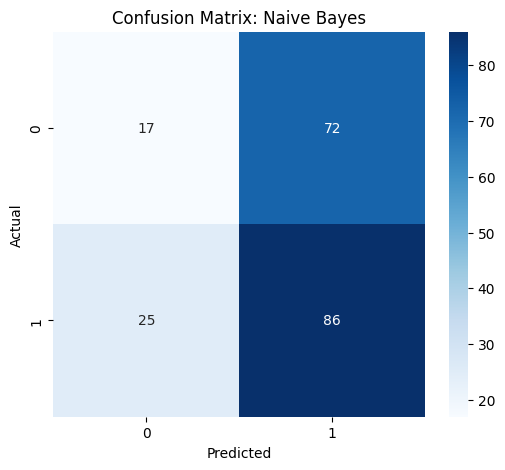

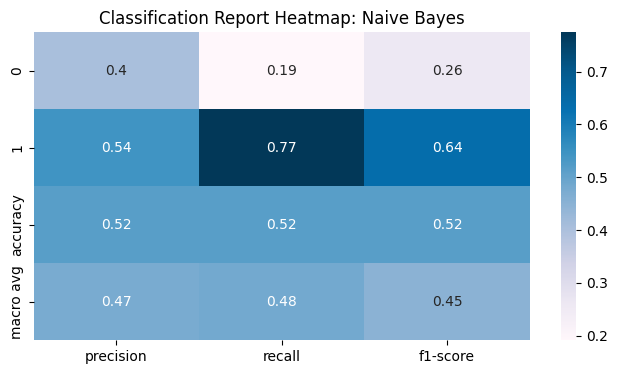

In [36]:
results = []

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    # Calculate metrics
    train_accuracy = accuracy_score(y_train, pred_train)
    train_precision = precision_score(y_train, pred_train, average='weighted')
    train_recall = recall_score(y_train, pred_train, average='weighted')
    train_f1 = f1_score(y_train, pred_train, average='weighted')

    test_accuracy = accuracy_score(y_test, pred_test)
    test_precision = precision_score(y_test, pred_test, average='weighted')
    test_recall = recall_score(y_test, pred_test, average='weighted')
    test_f1 = f1_score(y_test, pred_test, average='weighted')

    results.append({
        "Name": name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train Precision": train_precision,
        "Test Precision": test_precision,
        "Train Recall": train_recall,
        "Test Recall": test_recall,
        "Train F1": train_f1,
        "Test F1": test_f1
    })


    cm = confusion_matrix(y_test, pred_test)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    report = classification_report(y_test, pred_test, output_dict=True)
    df = pd.DataFrame(report).transpose()

    plt.figure(figsize=(8,4))
    sns.heatmap(df.iloc[:-1, :-1], annot=True, cmap="PuBu")
    plt.title(f"Classification Report Heatmap: {name}")
    plt.show()


In [37]:
res = pd.DataFrame(results)
res

,Name,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
0,Logistic Regression,0.62875,0.545,0.642699,0.417066,0.62875,0.545,0.495779,0.400058
1,Support Vector,0.62500,0.555,0.390625,0.308025,0.62500,0.555,0.480769,0.396174
2,KNN,0.68625,0.510,0.676272,0.476408,0.68625,0.510,0.675192,0.466673
3,Decision Tree,0.76125,0.480,0.759686,0.461203,0.76125,0.480,0.760319,0.462784
4,Random Forest,0.76125,0.475,0.757638,0.439900,0.76125,0.475,0.754603,0.440573
5,Naive Bayes,0.59625,0.515,0.554705,0.482208,0.59625,0.515,0.553025,0.470366


In [38]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

results = []


for C, penalty, solver in itertools.product(
    param_grid["C"], param_grid["penalty"], param_grid["solver"]):
    
        model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=500)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        threshold_diff = 0.1  
        low_acc = 0.65        

        if train_acc - test_acc > threshold_diff and train_acc:
            status = "Overfitting"
        elif train_acc < low_acc and test_acc < low_acc:
            status = "Underfitting"
        else:
            status = "Good Fit"


        results.append({
            "C": C,
            "penalty": penalty,
            "solver": solver,
            "Train_Acc": train_acc,
            "Test_Acc": test_acc,
            "Fit_Status": status
        })
    

df_logreg = pd.DataFrame(results)
print(df_logreg)


        C penalty     solver  Train_Acc  Test_Acc    Fit_Status
0    0.01      l1  liblinear    0.62500     0.555  Underfitting
1    0.01      l1       saga    0.62500     0.555  Underfitting
2    0.01      l2  liblinear    0.63000     0.555  Underfitting
3    0.01      l2       saga    0.63000     0.555  Underfitting
4    0.10      l1  liblinear    0.62500     0.555  Underfitting
5    0.10      l1       saga    0.62500     0.555  Underfitting
6    0.10      l2  liblinear    0.63000     0.555  Underfitting
7    0.10      l2       saga    0.62875     0.555  Underfitting
8    1.00      l1  liblinear    0.63000     0.555  Underfitting
9    1.00      l1       saga    0.63000     0.555  Underfitting
10   1.00      l2  liblinear    0.62875     0.550  Underfitting
11   1.00      l2       saga    0.63000     0.550  Underfitting
12  10.00      l1  liblinear    0.62875     0.545  Underfitting
13  10.00      l1       saga    0.63000     0.550  Underfitting
14  10.00      l2  liblinear    0.62875 

In [ ]:
param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10],
    "gamma": [ "auto"]
}

results = []

for kernel, C, gamma in itertools.product(param_grid["kernel"], param_grid["C"], param_grid["gamma"]):
    model = SVC(kernel=kernel, C=C, gamma=gamma)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    threshold_diff = 0.1  
    low_acc = 0.65        

    if train_acc - test_acc > threshold_diff and train_acc:
        status = "Overfitting"
    elif train_acc < low_acc and test_acc < low_acc:
        status = "Underfitting"
    else:
        status = "Good Fit"


    results.append({
        "kernel": kernel,
        "C": C,
        "gamma": gamma,
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Fit_Status": status
    })

df_svc = pd.DataFrame(results)
print(df_svc)


   kernel     C gamma  Train_Acc  Test_Acc    Fit_Status
0  linear   0.1  auto    0.62500     0.555  Underfitting
1  linear   1.0  auto    0.62500     0.555  Underfitting
2  linear  10.0  auto    0.62500     0.555  Underfitting
3     rbf   0.1  auto    0.62500     0.555  Underfitting
4     rbf   1.0  auto    0.66375     0.520   Overfitting
5     rbf  10.0  auto    0.73500     0.525   Overfitting


In [40]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1=Manhattan, 2=Euclidean
}

results = []

for n_neighbors, weights, p in itertools.product(
    param_grid["n_neighbors"], param_grid["weights"], param_grid["p"]):
    
    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    threshold_diff = 0.1  
    low_acc = 0.65        

    if train_acc - test_acc > threshold_diff and train_acc:
        status = "Overfitting"
    elif train_acc < low_acc and test_acc < low_acc:
        status = "Underfitting"
    else:
        status = "Good Fit"


    results.append({
        "n_neighbors": n_neighbors,
        "weights": weights,
        "p": p,
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Fit_Status": status
    })

df_knn = pd.DataFrame(results)
print(df_knn)


    n_neighbors   weights  p  Train_Acc  Test_Acc   Fit_Status
0             3   uniform  1    0.68625     0.495  Overfitting
1             3   uniform  2    0.67750     0.505  Overfitting
2             3  distance  1    0.74000     0.495  Overfitting
3             3  distance  2    0.74000     0.505  Overfitting
4             5   uniform  1    0.68250     0.485  Overfitting
5             5   uniform  2    0.68625     0.510  Overfitting
6             5  distance  1    0.75625     0.485  Overfitting
7             5  distance  2    0.75750     0.510  Overfitting
8             7   uniform  1    0.66625     0.490  Overfitting
9             7   uniform  2    0.66625     0.495  Overfitting
10            7  distance  1    0.75875     0.485  Overfitting
11            7  distance  2    0.76125     0.495  Overfitting
12            9   uniform  1    0.66375     0.505  Overfitting
13            9   uniform  2    0.66500     0.515  Overfitting
14            9  distance  1    0.76125     0.490  Over

In [41]:
param_grid = {
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 4]
}
results = []

for max_depth, min_samples_split, min_samples_leaf in itertools.product(
    param_grid["max_depth"], param_grid["min_samples_split"], param_grid["min_samples_leaf"]
):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    threshold_diff = 0.1  
    low_acc = 0.65       

    if train_acc - test_acc > threshold_diff and train_acc:
        status = "Overfitting"
    elif train_acc < low_acc and test_acc < low_acc:
        status = "Underfitting"
    else:
        status = "Good Fit"

    results.append({
        "max_depth": max_depth,
        "min_sam_split": min_samples_split,
        "min_sam_leaf": min_samples_leaf,
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Fit_Status": status
    })

df_dt = pd.DataFrame(results)
print(df_dt)


    max_depth  min_sam_split  min_sam_leaf  Train_Acc  Test_Acc    Fit_Status
0         NaN              2             2    0.70875     0.495   Overfitting
1         NaN              2             4    0.69250     0.500   Overfitting
2         NaN              5             2    0.70875     0.490   Overfitting
3         NaN              5             4    0.69250     0.500   Overfitting
4         5.0              2             2    0.64375     0.555  Underfitting
5         5.0              2             4    0.64000     0.555  Underfitting
6         5.0              5             2    0.64375     0.555  Underfitting
7         5.0              5             4    0.64000     0.555  Underfitting
8        10.0              2             2    0.68500     0.530   Overfitting
9        10.0              2             4    0.67375     0.520   Overfitting
10       10.0              5             2    0.68500     0.545   Overfitting
11       10.0              5             4    0.67375     0.520 

In [52]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

results = []

for n_estimators, max_depth, min_samples_split in itertools.product(
    param_grid["n_estimators"], param_grid["max_depth"], param_grid["min_samples_split"]
):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    threshold_diff = 0.1  
    low_acc = 0.65        

    if train_acc - test_acc > threshold_diff and train_acc:
        status = "Overfitting"
    elif train_acc < low_acc and test_acc < low_acc:
        status = "Underfitting"
    else:
        status = "Good Fit"

    results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samp_split": min_samples_split,
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Fit_Status": status
    })

df_rf = pd.DataFrame(results)
print(df_rf)


    n_estimators  max_depth  min_samp_split  Train_Acc  Test_Acc   Fit_Status
0             50        NaN               2    0.76125     0.490  Overfitting
1             50        NaN               5    0.75000     0.505  Overfitting
2             50        5.0               2    0.66000     0.530  Overfitting
3             50        5.0               5    0.66000     0.535  Overfitting
4             50       10.0               2    0.74625     0.520  Overfitting
5             50       10.0               5    0.72500     0.515  Overfitting
6            100        NaN               2    0.76125     0.490  Overfitting
7            100        NaN               5    0.75250     0.490  Overfitting
8            100        5.0               2    0.65500     0.545  Overfitting
9            100        5.0               5    0.65500     0.540  Overfitting
10           100       10.0               2    0.74500     0.530  Overfitting
11           100       10.0               5    0.72500     0.495

In [43]:
param_grid = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

results = []

for var_smoothing in param_grid["var_smoothing"]:
    model = GaussianNB(var_smoothing=var_smoothing)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    threshold_diff = 0.1  
    low_acc = 0.65       

    if train_acc - test_acc > threshold_diff and train_acc:
        status = "Overfitting"
    elif train_acc < low_acc and test_acc < low_acc:
        status = "Underfitting"
    else:
        status = "Good Fit"


    results.append({
        "var_smoothing": var_smoothing,
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Fit_Status": status
    })

df_nb = pd.DataFrame(results)
print(df_nb)


   var_smoothing  Train_Acc  Test_Acc    Fit_Status
0   1.000000e-09    0.59625     0.515  Underfitting
1   1.000000e-08    0.59625     0.515  Underfitting
2   1.000000e-07    0.59625     0.515  Underfitting
3   1.000000e-06    0.59625     0.515  Underfitting
4   1.000000e-05    0.59625     0.515  Underfitting


In [44]:
#cross_val_score(SVC(kernel = 'linear', C = 15, gamma = 'auto'), X,y,cv = 5)

In [45]:
# parm = { 'C' : [1,15,25,20],
#     'kernel' : ['rbf','linear']
# }
# clf = GridSearchCV(SVC(gamma = 'auto'),parm, cv = 5, return_train_score = False)

# clf.fit(X,y)
# p = pd.DataFrame(clf.cv_results_)

In [46]:
# clf.best_params_

In [47]:
# clf.best_score_

In [48]:
# p

In [49]:
# p[['param_C','param_kernel','mean_test_score']]

In [50]:
# Example for Logistic Regression 
# param_grid = { 
# 'C': [0.01, 0.1, 1, 10], 
# 'penalty': ['l1', 'l2'], 
# 'solver': ['liblinear', 'saga'] 
# } 
# grid = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=5, scoring='accuracy') 
# grid.fit(X, y) 
# print("Best Params:", grid.best_params_) 
# print("Best Accuracy:", grid.best_score_)

In [51]:
# grid.best_params_